#### Methods for reading HDF5 files, analyzing data and plotting graphs.

Current methods/functions were developed to read, analyze, plot and write data from Carcara-X (LNLS) scannings.

The scannings are relative to the movement of Caracara's mirror motors, slits and camera.

In [1]:
from caxscripts.scananalysis import *

/opt/mamba_files/mamba/envs/sirius/lib/python3.9/site-packages/epics/ca.py:28: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


### Main entry for data reading.

In [15]:
# workdir = "/ibira/lnls/beamlines/carcara/Carcara-X/data"
workdir = "/home/arnaldo.filho/Carcara/measurement/2026-03-19"
file_pattern = r"mirror_tx_pass[01][0-9]*"


def main(workdir, file_pattern):
    """Main function to load data and generate plots."""
    files   = files_in_directory(workdir, file_pattern)
    dataset = data_from_h5_files(files)
    print(f" Loaded {len(files)} files matching pattern "
          f"'{file_pattern}' \n from '{workdir}'\n Files:")

    for f in files:
        print(f" * {f}")
    return dataset


if __name__ == "__main__":

    # observable = 'centroid'
    # observable = 'photocollector'
    observable = 'tx'
    pass_interval = (0, 9)
    item_interval = (0, None)
    dataset = main(workdir, file_pattern)

 Loaded 10 files matching pattern 'mirror_tx_pass[01][0-9]*' 
 from '/home/arnaldo.filho/Carcara/measurement/2026-03-19'
 Files:
 * /home/arnaldo.filho/Carcara/measurement/2026-03-19/mirror_tx_pass01-20260319_135203.hdf5
 * /home/arnaldo.filho/Carcara/measurement/2026-03-19/mirror_tx_pass02-20260319_140127.hdf5
 * /home/arnaldo.filho/Carcara/measurement/2026-03-19/mirror_tx_pass03-20260319_140815.hdf5
 * /home/arnaldo.filho/Carcara/measurement/2026-03-19/mirror_tx_pass04-20260319_141205.hdf5
 * /home/arnaldo.filho/Carcara/measurement/2026-03-19/mirror_tx_pass05-20260319_141544.hdf5
 * /home/arnaldo.filho/Carcara/measurement/2026-03-19/mirror_tx_pass06-20260319_141935.hdf5
 * /home/arnaldo.filho/Carcara/measurement/2026-03-19/mirror_tx_pass07-20260319_142327.hdf5
 * /home/arnaldo.filho/Carcara/measurement/2026-03-19/mirror_tx_pass08-20260319_142753.hdf5
 * /home/arnaldo.filho/Carcara/measurement/2026-03-19/mirror_tx_pass09-20260319_143126.hdf5
 * /home/arnaldo.filho/Carcara/measurement/

#### Evaluate the differences between first and last position.
Check rotation Rz due to Tx movement.
Compute accumulated variation through scans.

In [ ]:
motors = ['mirror.tx',
          'mirror.ry',
          'mirror.y1',
          'mirror.y2',
          'mirror.y3',
          'mirror.cs_tx',
          'mirror.cs_ty',
          'mirror.cs_rx',
          'mirror.cs_rz',
          ]

for motor in motors:
    centroid_x_delta_plot(dataset, motor, *pass_interval)

### Observable plot for all passes.

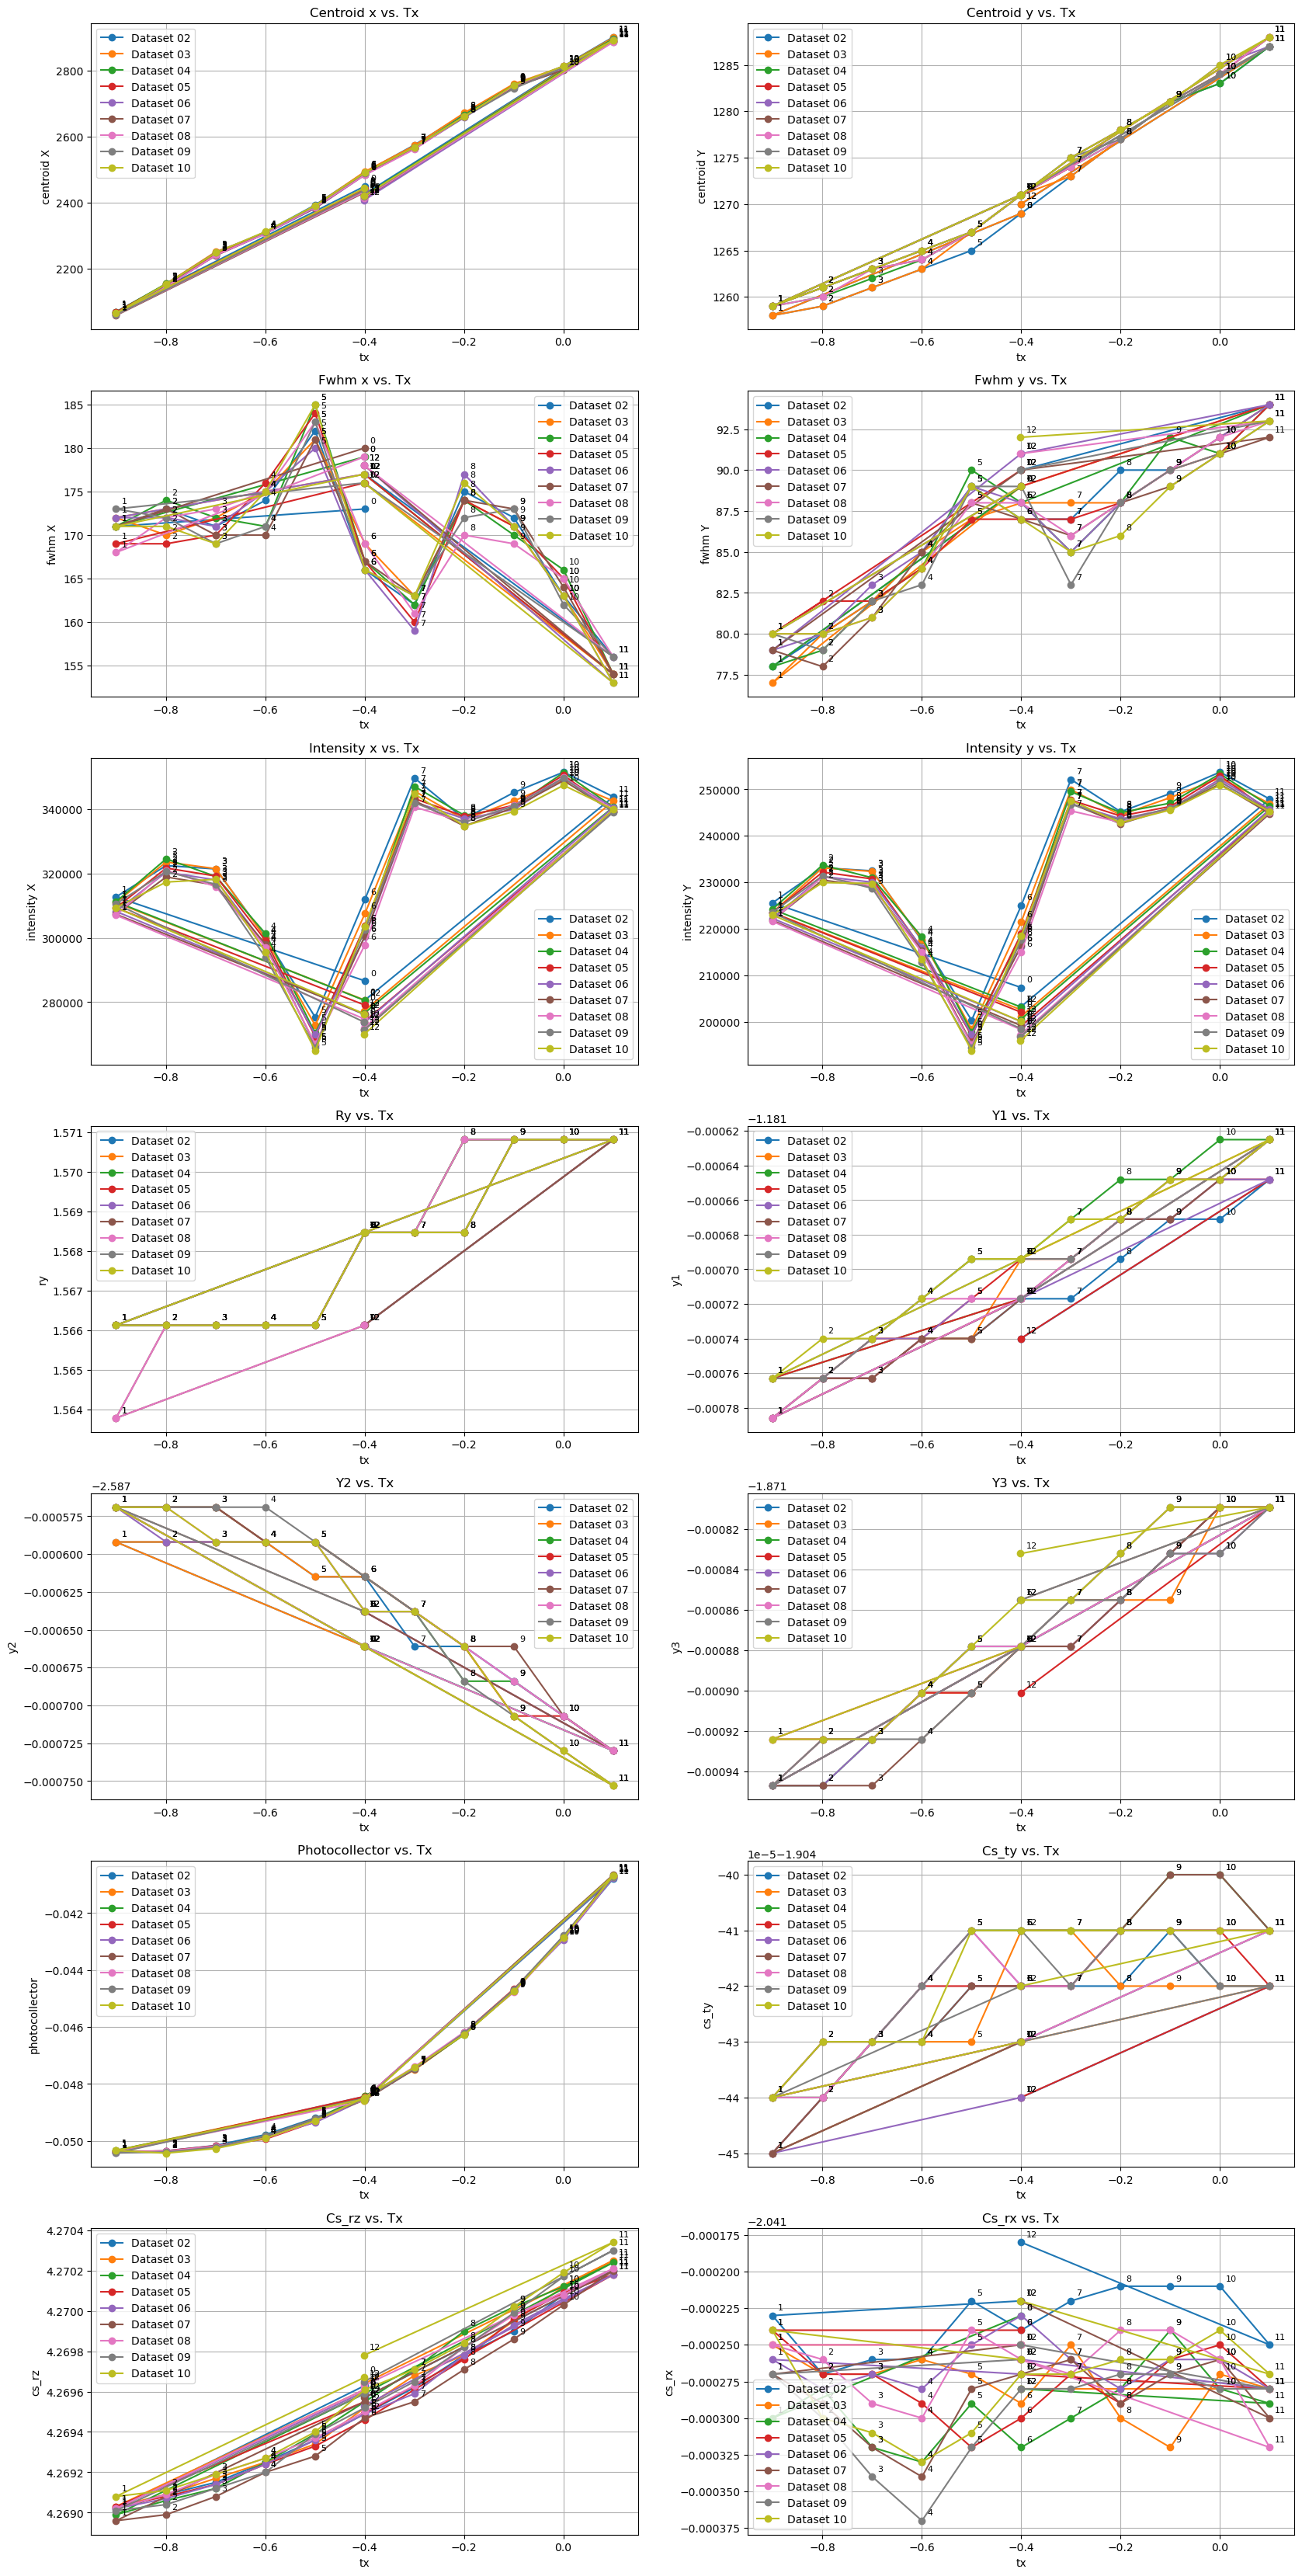

In [5]:
# observables = ['centroid']
observables = [
    'ry', 'y1', 'y2', 'y3',
    'photocollector',
    'centroid',
    'fwhm',
    'intensity',
    'cs_ty',
    'cs_rz',
    'cs_rx',
    ]

pass_interval = (1, 9)  # (0, 9)
item_interval = (0, 13)  # (1, 12)

# Chose set interval of scans to plot.
first_pass, last_pass = pass_interval
# sel_data = data
sel_data = dict(list(dataset.items())[first_pass:last_pass+1])

fr, upto = item_interval

scan_plot(sel_data, observables, first_item=fr, last_item=upto)

#### Statistics (avg, std dev, median) after a set of scans.

#### Show centroid following initial tx.

/tmp/ipykernel_325321/2770333915.py:15: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  ctx_0.append(np.array([tx0, cx0]))
/tmp/ipykernel_325321/2770333915.py:19: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  ctx_m.append(np.array([txm, cxm]))
/tmp/ipykernel_325321/2770333915.py:23: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  ctx_f.

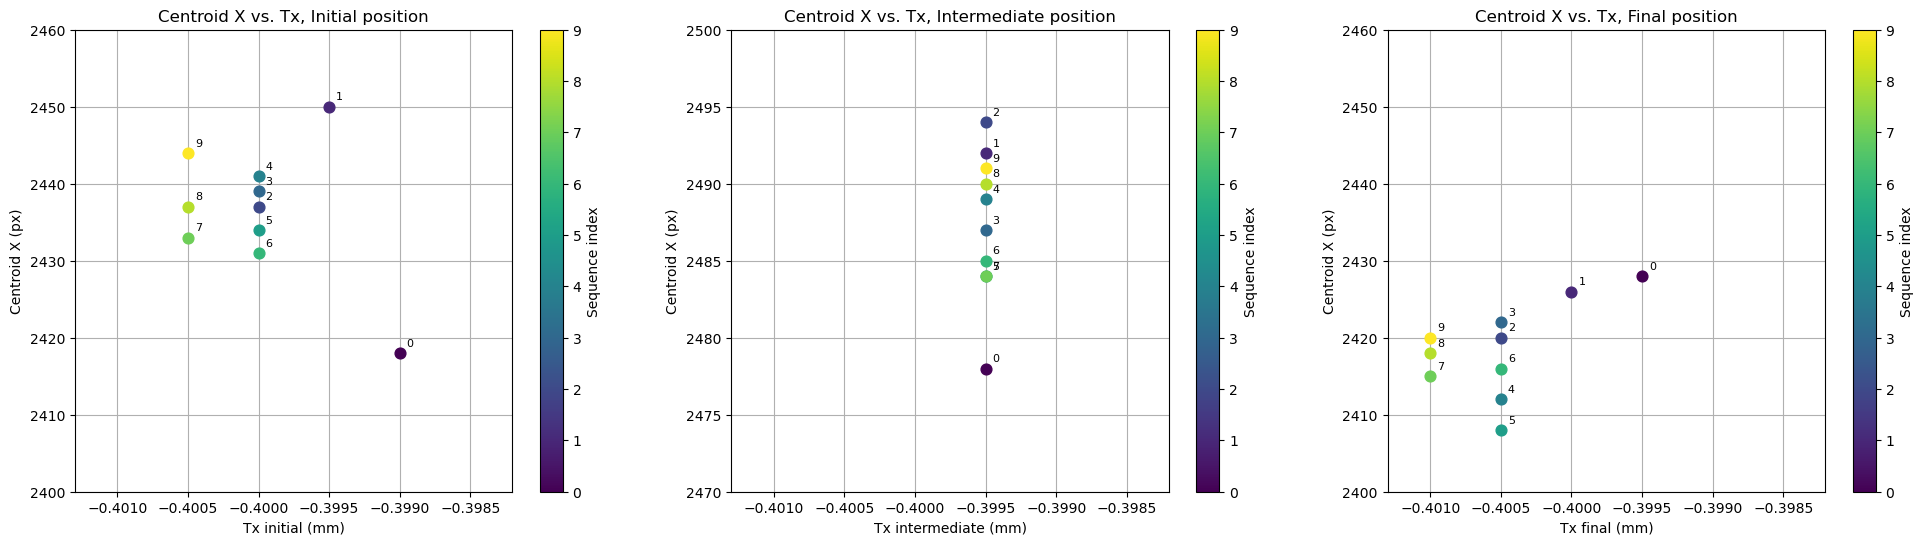

In [6]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

ctx_0 = []
ctx_m = []
ctx_f = []
npti = 0
nptf = 12

for data in dataset.values():
    bc  = beam_centroid(data, 'mirror.tx')
    tx0 = bc[npti][0]
    cx0 = bc[npti][1]
    ctx_0.append(np.array([tx0, cx0]))

    txm = bc[(npti + nptf) // 2][0]
    cxm = bc[(npti + nptf) // 2][1]
    ctx_m.append(np.array([txm, cxm]))

    txf = bc[nptf][0]
    cxf = bc[nptf][1]
    ctx_f.append(np.array([txf, cxf]))

ctx_0 = np.array(ctx_0)
ctx_m = np.array(ctx_m)
ctx_f = np.array(ctx_f)

n = len(ctx_0)
colors = cm.viridis(np.linspace(0, 1, n))

fig, (axx, axc, axy) = plt.subplots(1, 3, figsize=(24, 6))

for i, (idx, yv) in enumerate(ctx_0):
    axx.scatter(idx, yv[0], color=colors[i], zorder=3, s=60)
    axx.annotate(str(i), (idx, yv[0]), textcoords='offset points',
                 xytext=(5, 5), fontsize=8)

for i, (idx, yv) in enumerate(ctx_m):
    axc.scatter(idx, yv[0], color=colors[i], zorder=3, s=60)
    axc.annotate(str(i), (idx, yv[0]), textcoords='offset points',
                 xytext=(5, 5), fontsize=8)

for i, (idx, yv) in enumerate(ctx_f):
    axy.scatter(idx, yv[0], color=colors[i], zorder=3, s=60)
    axy.annotate(str(i), (idx, yv[0]), textcoords='offset points',
                 xytext=(5, 5), fontsize=8)


sm = plt.cm.ScalarMappable(cmap='viridis',
                            norm=plt.Normalize(vmin=0, vmax=n - 1))
plt.colorbar(sm, ax=axx, label='Sequence index')
plt.colorbar(sm, ax=axc, label='Sequence index')
plt.colorbar(sm, ax=axy, label='Sequence index')

xmin, xmax = np.min(ctx_0[:, 0]) * 1.002, np.max(ctx_0[:, 0]) * 0.998

axx.grid(True)
axx.set_title("Centroid X vs. Tx, Initial position")
axx.set_xlabel('Tx initial (mm)')
axx.set_ylabel('Centroid X (px)')
axx.set_xlim(xmin, xmax)
axx.set_ylim(2400, 2460)

axc.grid(True)
axc.set_title("Centroid X vs. Tx, Intermediate position")
axc.set_xlabel('Tx intermediate (mm)')
axc.set_ylabel('Centroid X (px)')
axc.set_xlim(xmin, xmax)
axc.set_ylim(2470, 2500)
axc.grid(True)

axy.grid(True)
axy.set_title("Centroid X vs. Tx, Final position")
axy.set_xlabel('Tx final (mm)')
axy.set_ylabel('Centroid X (px)')
axy.set_xlim(xmin, xmax)
axy.set_ylim(2400, 2460)

plt.show()

#### Compare centroids at the beginning, middle and end points of each pass.

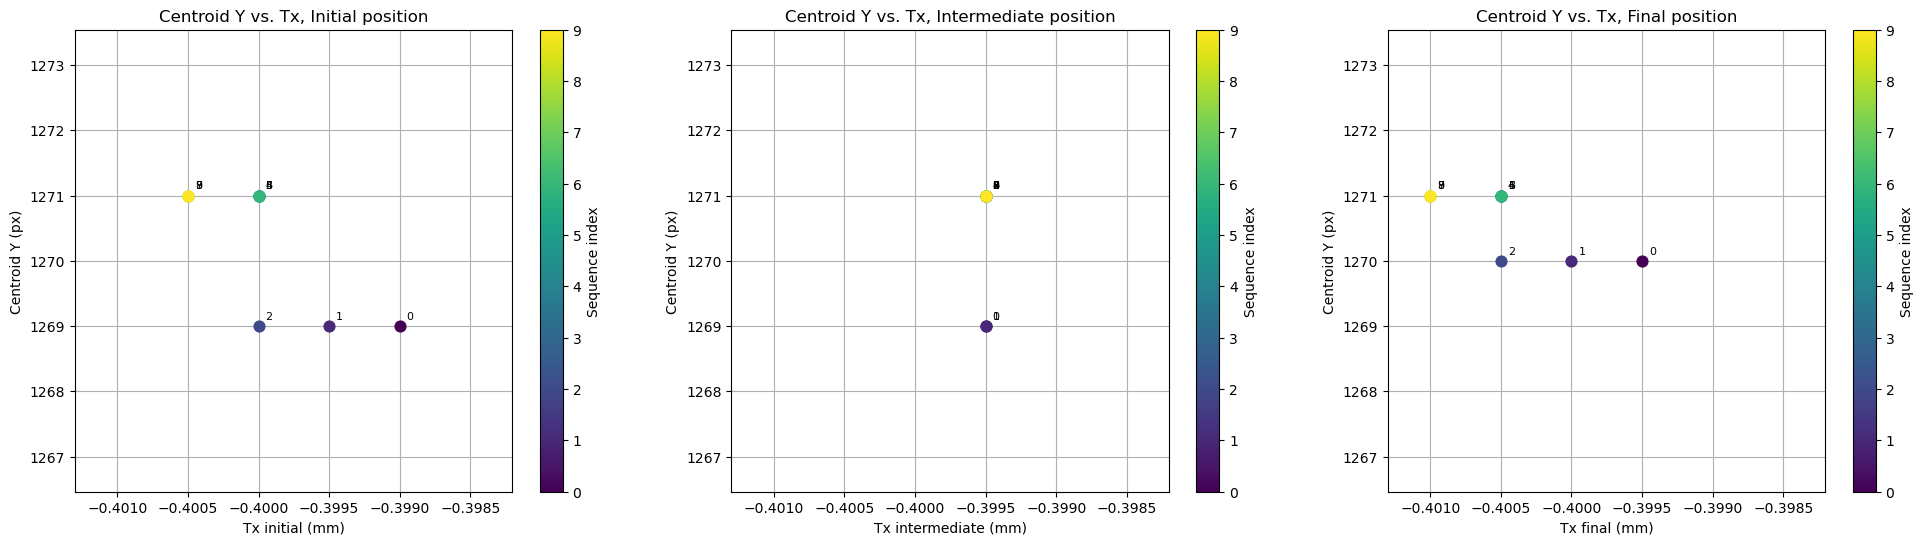

In [7]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

cty_0 = []
cty_m = []
cty_f = []
npti = 0
nptf = 12

for data in dataset.values():
    bc  = beam_centroid(data, 'mirror.tx')
    tx0 = bc[npti][0]
    cy0 = bc[npti][1]
    cty_0.append(np.array([tx0, cy0[1]]))

    txm = bc[(npti + nptf) // 2][0]
    cym = bc[(npti + nptf) // 2][1]
    cty_m.append(np.array([txm, cym[1]]))

    txf = bc[nptf][0]
    cyf = bc[nptf][1]
    cty_f.append(np.array([txf, cyf[1]]))

cty_0 = np.array(cty_0)
cty_m = np.array(cty_m)
cty_f = np.array(cty_f)

n = len(cty_0)
colors = cm.viridis(np.linspace(0, 1, n))

fig, (axx, axc, axy) = plt.subplots(1, 3, figsize=(24, 6))

for i, (idx, cy) in enumerate(cty_0):
    axx.scatter(idx, cy, color=colors[i], zorder=3, s=60)
    axx.annotate(str(i), (idx, cy), textcoords='offset points',
                 xytext=(5, 5), fontsize=8)

for i, (idx, cy) in enumerate(cty_m):
    axc.scatter(idx, cy, color=colors[i], zorder=3, s=60)
    axc.annotate(str(i), (idx, cy), textcoords='offset points',
                 xytext=(5, 5), fontsize=8)

for i, (idx, cy) in enumerate(cty_f):
    axy.scatter(idx, cy, color=colors[i], zorder=3, s=60)
    axy.annotate(str(i), (idx, cy), textcoords='offset points',
                 xytext=(5, 5), fontsize=8)


sm = plt.cm.ScalarMappable(cmap='viridis',
                            norm=plt.Normalize(vmin=0, vmax=n - 1))
plt.colorbar(sm, ax=axx, label='Sequence index')
plt.colorbar(sm, ax=axc, label='Sequence index')
plt.colorbar(sm, ax=axy, label='Sequence index')

xmin, xmax = np.min(cty_0[:, 0]) * 1.002, np.max(cty_0[:, 0]) * 0.998
ymin, ymax = np.min(cty_0[:, 1]) * 0.998, np.max(cty_0[:, 1]) * 1.002

axx.grid(True)
axx.set_title("Centroid Y vs. Tx, Initial position")
axx.set_xlabel('Tx initial (mm)')
axx.set_ylabel('Centroid Y (px)')
axx.set_xlim(xmin, xmax)
axx.set_ylim(ymin, ymax)

axc.grid(True)
axc.set_title("Centroid Y vs. Tx, Intermediate position")
axc.set_xlabel('Tx intermediate (mm)')
axc.set_ylabel('Centroid Y (px)')
axc.set_xlim(xmin, xmax)
axc.set_ylim(ymin, ymax)
axc.grid(True)

axy.grid(True)
axy.set_title("Centroid Y vs. Tx, Final position")
axy.set_xlabel('Tx final (mm)')
axy.set_ylabel('Centroid Y (px)')
axy.set_xlim(xmin, xmax)
axy.set_ylim(ymin, ymax)

plt.show()

#### Smoothed curves (savgol filter) to test centroid calculations.

In [ ]:
import numpy as np
# from scipy.signal import savgol_filter

img = dataset['01']['scan-0012']['dvf_B1']['data']
yv = np.sum(img, axis=0).argmax()
cy = np.sum(img, axis=1).argmax()

# FWHMs
x_profile = img[cy, :]
y_profile = img[:, yv]

halfx = x_profile.max() / 2
halfy = y_profile.max() / 2


xsmooth = savgol_filter(x_profile, window_length=13, polyorder=2)
ysmooth = savgol_filter(y_profile, window_length=13, polyorder=2)

xmaxraw = np.argmax(x_profile)
ymaxraw = np.argmax(y_profile)
xmax = np.argmax(xsmooth)
ymax = np.argmax(ysmooth)

print(f"Raw centroid: ({xmaxraw}, {ymaxraw}),\n"
      f" Smoothed centroid: ({xmax}, {ymax})")

fwhm_x_raw = np.sum(x_profile > halfx)
fwhm_y_raw = np.sum(y_profile > halfy)
fwhm_x = np.sum(xsmooth > halfx)
fwhm_y = np.sum(ysmooth > halfy)

print(f"FWHM X (raw): {fwhm_x_raw} pixels, FWHM Y (raw): {fwhm_y_raw} pixels")
print(f"FWHM X: {fwhm_x} pixels, FWHM Y: {fwhm_y} pixels")


# plt.plot(x_profile[x_profile > halfx], label='x')
# plt.plot(y_profile[y_profile > halfy], label='y')
plt.plot(xsmooth[xsmooth > halfx], label='x smooth')
plt.plot(ysmooth[ysmooth > halfy], label='y smooth')
# plt.plot([0, len(x_profile)],
#          [x_profile.max() / 2, x_profile.max() / 2],
#          'k--', label='Half max')
plt.grid(True)
plt.legend()


#### Mean and median of a single curve, for testing.

In [ ]:
observable = 'fwhm'
stats = observable_statistics(dataset, observable)
# print(f" observable = '{observable}'")
# for key, value in stats.items():
#     print(f">>> {key}: {value}  \t ({value.shape})\n")


 idx: (13,),
 yv: (13,), dy: (13,),
 my: (13,)


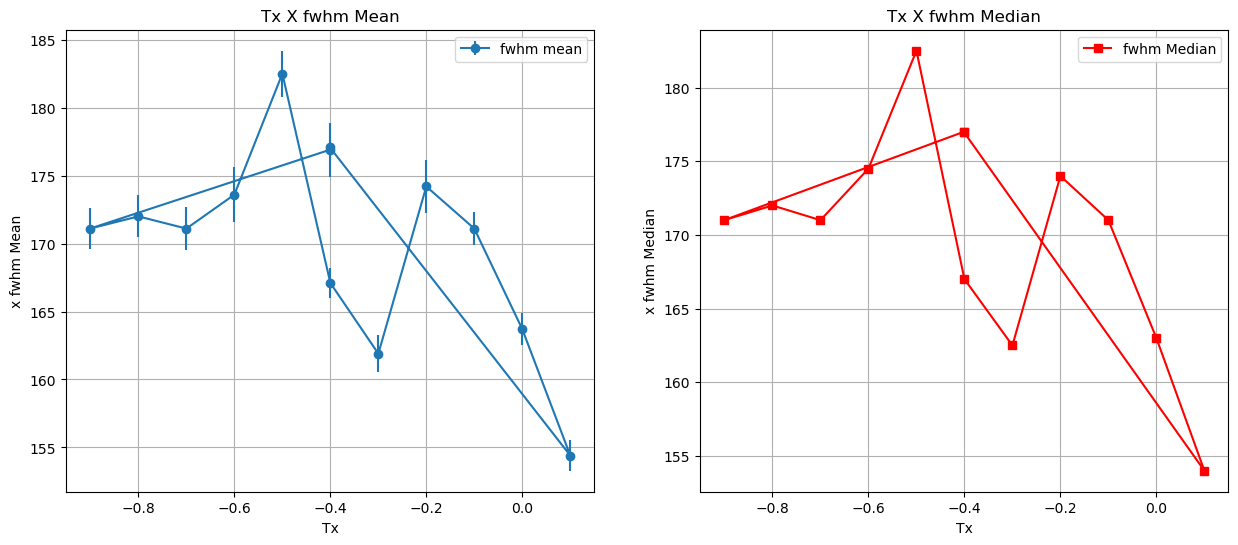

In [22]:
idx = stats['xval']
yv = stats['mean'][0]
#  cy = stats['mean'][1]
dy = stats['std_dev'][0]
# dy = stats['std_dev'][1]
my = stats['median'][0]
# my = stats['median'][1]

fig, (axmx, axmy) = plt.subplots(1, 2, figsize=(15, 6))

print(f" idx: {idx.shape},\n"
      f" yv: {yv.shape},"
      # f" cy: {cy.shape},\n"
      # f" dx: {dx.shape},"
      f" dy: {dy.shape},\n"
      # f" mx: {mx.shape},"
      f" my: {my.shape}")

axmx.errorbar(idx, yv, yerr=dy, fmt='o-', label=f'{observable} mean')
axmx.set_ylabel(f'x {observable} Mean')
axmx.set_title(f'Tx X {observable} Mean')

axmy.set_ylabel(f'x {observable} Median')
axmy.set_title(f'Tx X {observable} Median')
axmy.plot(idx, my, 's-', label=f'{observable} Median', color='red')

for ax in [axmx, axmy]:
    ax.grid(True)
    ax.set_xlabel('Tx')
    ax.legend()
    ax.grid(True)

### Sequence of beam images.

In [ ]:
# Working directory for saving the plots.
wdir = "/home/ABTLUS/arnaldo.filho/Beam_profiling/beam_profiles"

# Plot centroids and images for all datasets.
for scanpass, data in dataset.items():
    centroid_plot(data, scanpass, wdir=wdir, save_fmt='')


#### Evaluation of differences of centroid position along experimental passes.

In [9]:
data.keys()

dict_keys(['scan-0000', 'scan-0001', 'scan-0002', 'scan-0003', 'scan-0004', 'scan-0005', 'scan-0006', 'scan-0007', 'scan-0008', 'scan-0009', 'scan-0010', 'scan-0011', 'scan-0012'])

In [10]:
import numpy as np

pixsize = 0.48  # um/px

initfindiff = []
scandiff = []
for scanpass, data in dataset.items():
    print(f"\n##### Scan pass: {scanpass}")

    cent = observable_data(data, 'centroid')
    idx = cent[2][1:-1] * pixsize
    yv = cent[3][0][1:-1] * pixsize

    a, b = np.polyfit(idx, yv, 1)
    cxfit = a * idx + b
    c0a = cent[3][0][0] * pixsize
    c0b = cent[3][0][-1] * pixsize
    c0x = yv[len(yv) // 2]

    c0fit = a * idx[len(idx) // 2] + b

    print("Linear fit parameters:"
          f"               a = {a:.4f}, b = {b:.4f}")
    print("Initial and final centroid values:"
          f"   {c0a:.2f} → {c0b:.2f}")
    print("Central centroid value along scan:"
          f"   {c0x:.2f}")

    dinfin = (c0b / c0a - 1) * 100
    cdiff  = (c0x / c0a - 1) * 100
    scandiff.append(cdiff)
    initfindiff.append(dinfin)
    print("Centroid differences, relative to initial position:")
    print(f"\t at center, along scan:   {(c0x - c0a) / c0a * 100 :.2f}%")
    print(f"\t after scan:              {dinfin:.2f}%")
    print(f"\t at center, based on fit: {(c0fit - c0a) / c0a * 100 :.2f}%")

scandiff = np.array(scandiff)
initfindiff = np.array(initfindiff)


##### Scan pass: 01
Linear fit parameters:               a = 852.3384, b = 1355.0162
Initial and final centroid values:   1160.64 → 1165.44
Central centroid value along scan:   1189.44
Centroid differences, relative to initial position:
	 at center, along scan:   2.48%
	 after scan:              0.41%
	 at center, based on fit: 2.67%

##### Scan pass: 02
Linear fit parameters:               a = 839.7085, b = 1355.6919
Initial and final centroid values:   1176.00 → 1164.48
Central centroid value along scan:   1196.16
Centroid differences, relative to initial position:
	 at center, along scan:   1.71%
	 after scan:              -0.98%
	 at center, based on fit: 1.59%

##### Scan pass: 03
Linear fit parameters:               a = 840.5298, b = 1355.9803
Initial and final centroid values:   1169.76 → 1161.60
Central centroid value along scan:   1197.12
Centroid differences, relative to initial position:
	 at center, along scan:   2.34%
	 after scan:              -0.70%
	 at center, based o

#### Correlation analysis.


Correlation coefficient between initial/final change and scan change: 0.7546
Best correlation: 0.7546407859563501
Shift needed: 0 indices
 Initial/final mean and std. deviation values: -0.7335 ± 0.4213
 Scan/initial mean and std. deviation values: 2.0939 ± 0.2097


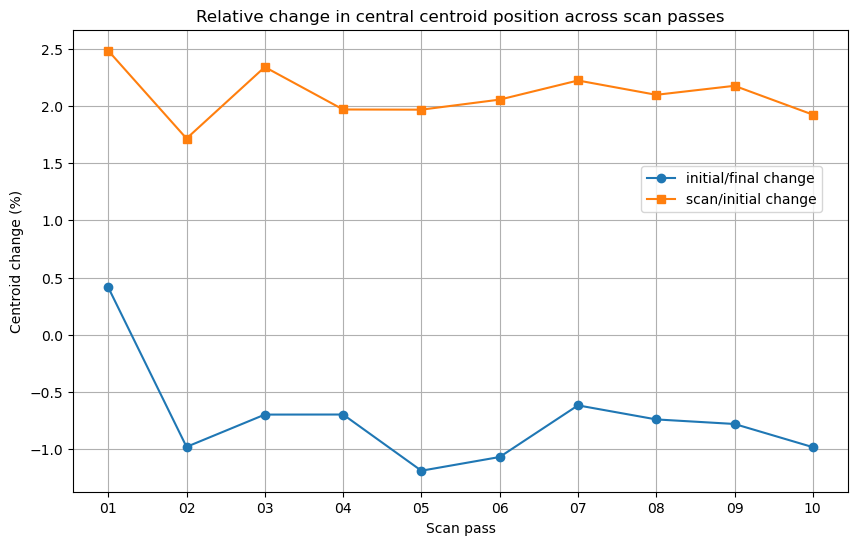

In [11]:
ifdiff = np.array(initfindiff)    # - np.mean(initfindiff)
sdiff  = np.array(scandiff)       # - np.mean(scandiff)

corr_mat = np.corrcoef(sdiff, ifdiff)
print("\nCorrelation coefficient between"
      f" initial/final change and scan change: {corr_mat[0, 1]:.4f}")

# cross_correlation = np.correlate(sdiff, ifdiff, mode='same')
cc = correlate(sdiff, ifdiff)
lags = np.arange(-len(sdiff) + 1, len(sdiff))
best_lag = lags[np.argmax(cc)]
print(f"Best correlation: {np.max(cc)}")
print(f"Shift needed: {best_lag} indices")


# print("Cross-correlation between initial/final change and scan change:"
#       f" {cross_correlation}")

fig, axs = plt.subplots(figsize=(10, 6))
sc = np.array(list(dataset.keys()))
axs.plot(sc, ifdiff, marker='o', label='initial/final change')
axs.plot(sc, sdiff, marker='s', label='scan/initial change')
# ax.plot(sc, cc, marker='^',
#         label='cross-correlation (normalized)')
axs.grid(True)
# ax.set_ylim(0, max(max(ifdiff), max(sdiff)) * 1.2)
axs.set_xlabel('Scan pass')
axs.set_ylabel('Centroid change (%)')
axs.legend(loc='upper center', bbox_to_anchor=(0.85, 0.72))
axs.set_title('Relative change in central centroid position across scan passes')

print(" Initial/final mean and std. deviation values:"
      f" {np.mean(ifdiff):.4f} ± {np.std(ifdiff):.4f}")
print(" Scan/initial mean and std. deviation values:"
      f" {np.mean(sdiff):.4f} ± {np.std(sdiff):.4f}")

plt.show()

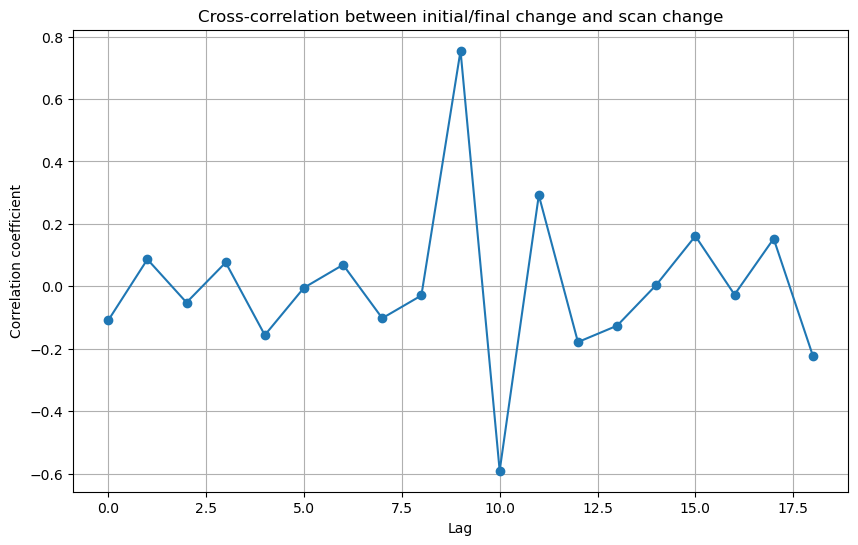

0.7546407859563501


In [12]:
fig, axs = plt.subplots(figsize=(10, 6))
axs.plot(cc, marker='o', label='initial/final change')
axs.grid(True)
axs.set_title("Cross-correlation between initial/final change and scan change")
axs.set_xlabel('Lag')
axs.set_ylabel('Correlation coefficient')
# ax.legend()
plt.show()
print(np.max(cc))

#### Linear fitting to centroid positions along a scanning.

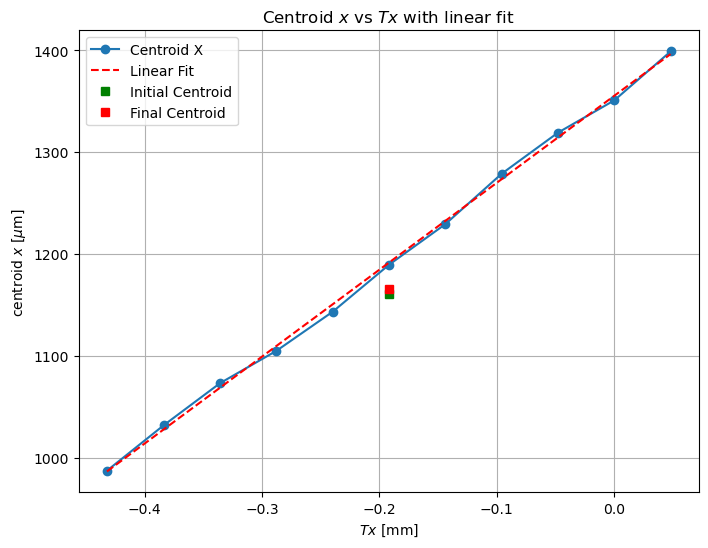

In [16]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(figsize=(8, 6))

data = dataset['01']
cent = observable_data(data, 'centroid')
idx = cent[2][1:-1] * pixsize
yv = cent[3][0][1:-1] * pixsize

a, b = np.polyfit(idx, yv, 1)
cxfit = a * idx + b
c0a = cent[3][0][0] * pixsize
c0b = cent[3][0][-1] * pixsize
# c0x = cx[len(cx) // 2]

c0fit = a * idx[len(idx) // 2] + b

axs.plot(idx, yv, 'o-', label='Centroid X')
axs.plot(idx, cxfit, 'r--', label='Linear Fit')
axs.plot(cent[2][0] * pixsize, c0a, 'gs', label='Initial Centroid')
axs.plot(cent[2][-1] * pixsize, c0b, 'rs', label='Final Centroid')
axs.set_xlabel(r'$Tx$ [mm]')
axs.set_ylabel(r'centroid $x$ [$\mu$m]')
axs.set_title(r'Centroid $x$ vs $Tx$ with linear fit')
axs.legend()
axs.grid(True)

#### Test with a specific scan frame.

ROI average: 1502.47, Mean: 4.70, Ratio (ROI/Mean): 319.44
-0.5995 2307 1263


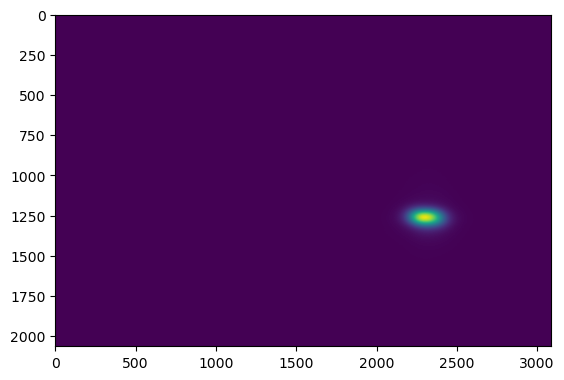

In [17]:
import matplotlib.pyplot as plt
import numpy as np

dx = 4
threshold = 10
data = dataset['03']
scandata = '0004'

img = data[f'scan-{scandata}']['dvf_B1']['data']
centroid = beam_centroid(data, 'mirror.tx')
idx, (yv, cy) = centroid[int(scandata)]

roi_avg = np.mean(img[cy-dx:cy+dx, yv-dx:yv+dx])
mean = np.mean(img)
ratio_rtom = roi_avg / mean

print(f"ROI average: {roi_avg:.2f}, Mean: {mean:.2f},"
      f" Ratio (ROI/Mean): {ratio_rtom:.2f}")

print(idx, yv, cy)
plt.imshow(img)
plt.show()

Centroid (dvf_B1): 2435, 1270


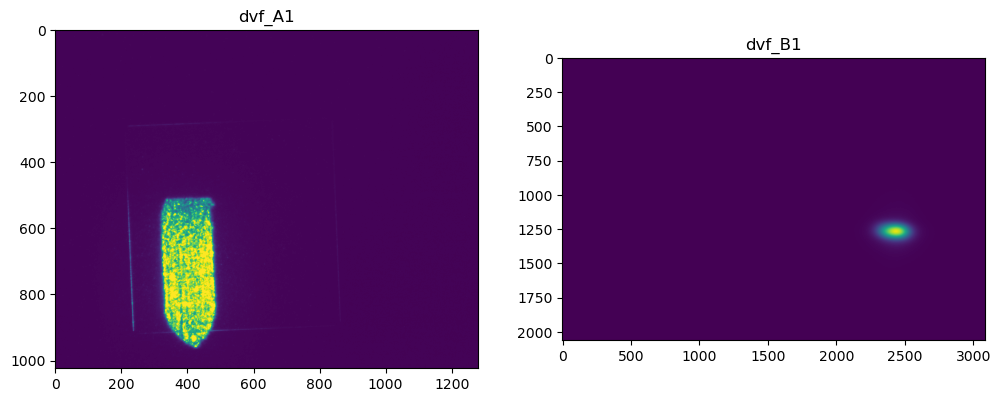

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

data = dataset['03']
scan = data['scan-0000']
img1 = scan['dvf_A1']['data']
img2 = scan['dvf_B1']['data']

yv = np.sum(img2, axis=0).argmax()
cy = np.sum(img2, axis=1).argmax()

ax1.imshow(img1, cmap='viridis')
ax1.set_title('dvf_A1')

ax2.imshow(img2, cmap='viridis')
ax2.set_title('dvf_B1')

print(f"Centroid (dvf_B1): {yv}, {cy}")